## Imports

In [15]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## Utils

In [16]:
def get_data_root():
  '''
    Ritorna il percorso della cartella contenente i dati in base all'ambiente di esecuzione.
  '''
  try:
      import google.colab
      from google.colab import drive

      try:
          drive.mount("/content/drive", force_remount=True)
          return "/content/drive/MyDrive/ColabContent/Data_analytics"
      except Exception:
          print("Drive non montabile")
          return "/content"

  except ImportError:
      return "../../data"

print(get_data_root())

../../data


## Global variables

In [17]:
DATA_ROOT = get_data_root()
DATASET_PATH = f"{DATA_ROOT}/Dataset2526/train.csv"
TRAIN_SET_PATH = f"{DATA_ROOT}/train_processed.csv"
VAL_SET_PATH = f"{DATA_ROOT}/val_processed.csv"
TEST_SET_PATH = f"{DATA_ROOT}/test_processed.csv"
SEED = 42

# Modeling (tradition ML models)

In [18]:
train = pd.read_csv(TRAIN_SET_PATH)
val = pd.read_csv(VAL_SET_PATH)
test = pd.read_csv(TEST_SET_PATH)

X_train = train.drop(columns=['grade'])
y_train = train["grade"]

X_val = val.drop(columns=['grade'])
y_val = val["grade"]

X_test = test.drop(columns=['grade'])
y_test = test["grade"]

print(f"TRAIN:\nX: {X_train.shape}\ny: {y_train.shape}")
print(f"VAL:\nX: {X_val.shape}\ny: {y_val.shape}")
print(f"TEST:\nX: {X_test.shape}\ny: {y_test.shape}")

# Dato che usiamo cross validation, bilanciamo il val_set per poterlo usare come train
rus = RandomUnderSampler(random_state=SEED)
X_val, y_val = rus.fit_resample(X_val, y_val)

TRAIN:
X: (33747, 38)
y: (33747,)
VAL:
X: (14830, 38)
y: (14830,)
TEST:
X: (14831, 38)
y: (14831,)


## 1. KNN

### Train knn

In [19]:
X_train_knn = np.concatenate([X_train, X_val], axis=0)
y_train_knn = np.concatenate([y_train, y_val], axis=0)

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis()),
    ('knn', KNeighborsClassifier(metric='manhattan'))
])

param_grid_knn = {
    'lda__n_components': [3, 5, 6], 
    'knn__n_neighbors': [11, 31, 51, 101, 201],
    'knn__weights': ['distance', 'uniform']
}

grid_search_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train_knn, y_train_knn)

print(f"Miglior score in Cross-Validation: {grid_search_knn.best_score_}")
print(f"Migliori parametri: {grid_search_knn.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Miglior score in Cross-Validation: 0.7821743249374393
Migliori parametri: {'knn__n_neighbors': 31, 'knn__weights': 'distance', 'lda__n_components': 6}


### Test knn

In [20]:
best_knn = grid_search_knn.best_estimator_

y_pred = best_knn.predict(X_test)


print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

/Users/leonardovorabbi/Data_Analytics_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Accuracy: 0.8275908569887398
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      2647
           1       0.88      0.84      0.86      3789
           2       0.86      0.84      0.85      3689
           3       0.78      0.82      0.80      2156
           4       0.70      0.72      0.71      1203
           5       0.62      0.52      0.57       711
           6       0.69      0.85      0.76       636

    accuracy                           0.83     14831
   macro avg       0.78      0.79      0.78     14831
weighted avg       0.83      0.83      0.83     14831



### Salvataggio pipeline

In [21]:
with open('../Test_module/models/knn_pipeline.save', 'wb') as f:
    pickle.dump(best_knn, f)

### Visualizzazione performance

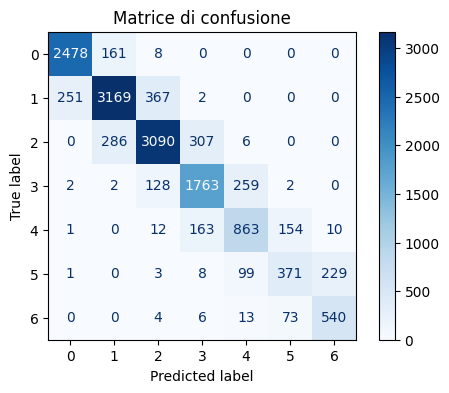

In [22]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(7))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matrice di confusione")
plt.show()

## 2. Random Forest

### Train random forest

In [23]:
X_train_rf = np.concatenate([X_train, X_val], axis=0)
y_train_rf = np.concatenate([y_train, y_val], axis=0)

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

# - n_estimators: numero di alberi (più sono, meglio è, ma aumenta il tempo)
# - max_depth: controlla l'overfitting (profondità dell'albero)
# - min_samples_split: numero minimo di campioni per dividere un nodo
param_grid_rf = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [5, 10, 20]
}

grid_rf = GridSearchCV(
    rf_pipeline, 
    param_grid_rf, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

In [24]:
grid_rf.fit(X_train_rf, y_train_rf)

print(f"Miglior score in Cross-Validation: {grid_rf.best_score_}")
print(f"Migliori parametri: {grid_rf.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits


/Users/leonardovorabbi/Data_Analytics_Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/leonardovorabbi/Data_Analytics_Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/leonardovorabbi/Data_Analytics_Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

Miglior score in Cross-Validation: 0.8532620096496748
Migliori parametri: {'rf__max_depth': 20, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}


### Test random forest

In [25]:
best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8992650529296743
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2647
           1       0.95      0.90      0.92      3789
           2       0.89      0.92      0.91      3689
           3       0.88      0.87      0.88      2156
           4       0.82      0.84      0.83      1203
           5       0.78      0.70      0.74       711
           6       0.77      0.89      0.82       636

    accuracy                           0.90     14831
   macro avg       0.86      0.87      0.87     14831
weighted avg       0.90      0.90      0.90     14831



/Users/leonardovorabbi/Data_Analytics_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


### Salvataggio pipeline

In [26]:
with open('../Test_module/models/rf_pipeline.save', 'wb') as f:
    pickle.dump(best_rf, f)

### Visualizzazione performance

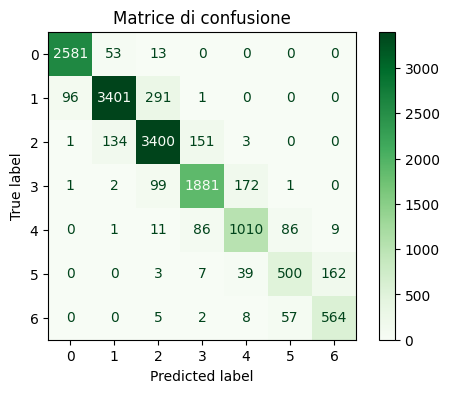

In [27]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(7))
disp.plot(cmap='Greens', ax=ax)
plt.title("Matrice di confusione")
plt.show()

## 3. SVM

### Train SVM

In [28]:
X_train_svm = np.concatenate([X_train, X_val], axis=0)
y_train_svm = np.concatenate([y_train, y_val], axis=0)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis()),
    ('svm', SVC(random_state=SEED))
])

# C: controlla la penalità degli errori (regolarizzazione)
# gamma: definisce l'influenza di un singolo esempio (solo per RBF)
param_grid_svm = {
    'lda__n_components': [3, 5, 6],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto'] 
}

grid_svm = GridSearchCV(
    svm_pipeline, 
    param_grid_svm, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

grid_svm.fit(X_train_svm, y_train_svm)

print(f"Miglior score in Cross-Validation: {grid_svm.best_score_}")
print(f"Migliori parametri: {grid_svm.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Miglior score in Cross-Validation: 0.7836951961401301
Migliori parametri: {'lda__n_components': 6, 'svm__C': 1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}


### Test SVM

In [29]:
best_svm = grid_svm.best_estimator_
y_pred = best_svm.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

/Users/leonardovorabbi/Data_Analytics_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Accuracy: 0.8315015845189131
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2647
           1       0.88      0.85      0.86      3789
           2       0.86      0.85      0.85      3689
           3       0.79      0.81      0.80      2156
           4       0.69      0.71      0.70      1203
           5       0.62      0.52      0.56       711
           6       0.70      0.85      0.77       636

    accuracy                           0.83     14831
   macro avg       0.78      0.79      0.78     14831
weighted avg       0.83      0.83      0.83     14831



### Salvataggio pipeline

In [30]:
with open('../Test_module/models/svm_pipeline.save', 'wb') as f:
    pickle.dump(best_svm, f)

### Visualizzazione performance

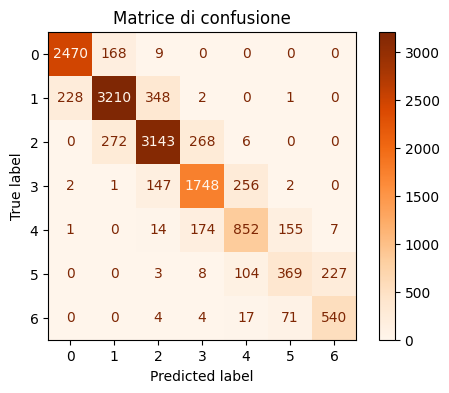

In [31]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(7))
disp.plot(cmap='Oranges', ax=ax)
plt.title("Matrice di confusione")
plt.show()